In [1]:
import pandas as pd
import numpy as np

## Import Data

In [2]:
data = pd.read_csv("olist_order_items_dataset.csv")

In [3]:
data.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [4]:
# Checking rows and columns
data.shape

(112650, 7)

In [5]:
data.info

<bound method DataFrame.info of                                 order_id  order_item_id  \
0       00010242fe8c5a6d1ba2dd792cb16214              1   
1       00018f77f2f0320c557190d7a144bdd3              1   
2       000229ec398224ef6ca0657da4fc703e              1   
3       00024acbcdf0a6daa1e931b038114c75              1   
4       00042b26cf59d7ce69dfabb4e55b4fd9              1   
...                                  ...            ...   
112645  fffc94f6ce00a00581880bf54a75a037              1   
112646  fffcd46ef2263f404302a634eb57f7eb              1   
112647  fffce4705a9662cd70adb13d4a31832d              1   
112648  fffe18544ffabc95dfada21779c9644f              1   
112649  fffe41c64501cc87c801fd61db3f6244              1   

                              product_id                         seller_id  \
0       4244733e06e7ecb4970a6e2683c13e61  48436dade18ac8b2bce089ec2a041202   
1       e5f2d52b802189ee658865ca93d83a8f  dd7ddc04e1b6c2c614352b383efe2d36   
2       c777355d18b72b67a

In [6]:
#Counting nulls
data.isnull().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [7]:
data.describe()

,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


In [8]:
data.dtypes

order_id                   str
order_item_id            int64
product_id                 str
seller_id                  str
shipping_limit_date        str
price                  float64
freight_value          float64
dtype: object

In [9]:
# Dataframe containing numeric columns
# I am doing this for my main analysis
numeric_df= data.select_dtypes(include=np.number)

In [10]:
numeric_df

,order_item_id,price,freight_value
0,1,58.90,13.29
1,1,239.90,19.93
2,1,199.00,17.87
3,1,12.99,12.79
4,1,199.90,18.14
...,...,...,...
112645,1,299.99,43.41
112646,1,350.00,36.53
112647,1,99.90,16.95
112648,1,55.99,8.72


In [11]:
#Dropping order_id because it will not be useful for this descriptive stats
numeric_df = numeric_df.drop(columns='order_item_id')

In [12]:
numeric_df.skew()

price            7.923208
freight_value    5.639870
dtype: float64

In [13]:
descriptive_stats = pd.DataFrame({
    "count": numeric_df.count(),
    "mean" : numeric_df.mean(),
    "median": numeric_df.median(),
    "variance": numeric_df.var(),
    "standard deviation": numeric_df.std(),
    "skewness": numeric_df.skew(),
    "kurtosis": numeric_df.kurt()
})

In [14]:
descriptive_stats

,count,mean,median,variance,standard deviation,skewness,kurtosis
price,112650,120.653739,74.99,33721.419531,183.633928,7.923208,120.828298
freight_value,112650,19.990320,16.26,249.842452,15.806405,5.639870,59.788253


In [15]:
descriptive_stats['abs_skewness'] = descriptive_stats['skewness'].abs()


In [16]:
descriptive_stats['abs_skewness']

price            7.923208
freight_value    5.639870
Name: abs_skewness, dtype: float64

In [17]:
descriptive_stats= descriptive_stats.sort_values("abs_skewness",ascending=False)

In [18]:
# Visualizing the distributions before deciding whether to transform them
import matplotlib.pyplot as plt
import seaborn as sns

Text(0.5, 1.0, 'Price Skewness')

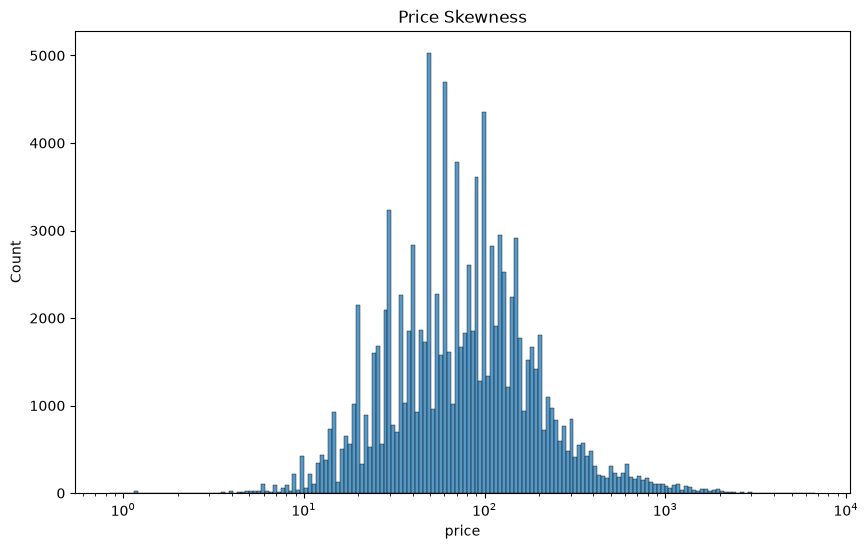

In [19]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(
  data=numeric_df,log_scale=True, x='price'
)
ax.set_title("Price Skewness")

Text(0.5, 1.0, 'Freight Skewness')

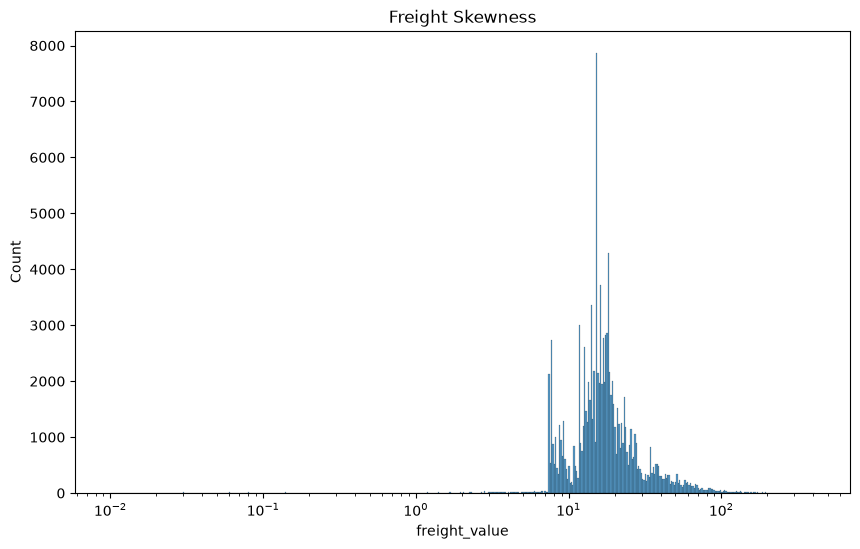

In [20]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(
  data=numeric_df,log_scale=True, x= 'freight_value'
)
ax.set_title("Freight Skewness")

In [21]:
#Quick check
print("Zeros in price:", (numeric_df['price'] == 0).sum())
print("Zeros in freight_value:", (numeric_df['freight_value'] == 0).sum())

Zeros in price: 0
Zeros in freight_value: 383


In [25]:
from sklearn.preprocessing import PowerTransformer

transformed_data = data.copy()

transformed_data["price_log"] = np.log1p(transformed_data["price"])

# Yeo-Johnson transformation for freight_value
yeo = PowerTransformer(method="yeo-johnson")

transformed_data["freight_value_yeo"] = yeo.fit_transform(
    transformed_data[["freight_value"]]
)

In [26]:
comparison = pd.DataFrame({
    "feature": ["price", "freight_value"],
    "original_skewness": [
        data["price"].skew(),
        data["freight_value"].skew()
    ],
    "transformation": [
        "log1p",
        "Yeo-Johnson"
    ],
    "transformed_skewness": [
        transformed_data["price_log"].skew(),
        transformed_data["freight_value_yeo"].skew()
    ]
})



In [27]:
comparison

,feature,original_skewness,transformation,transformed_skewness
0,price,7.923208,log1p,0.293529
1,freight_value,5.639870,Yeo-Johnson,-0.000212


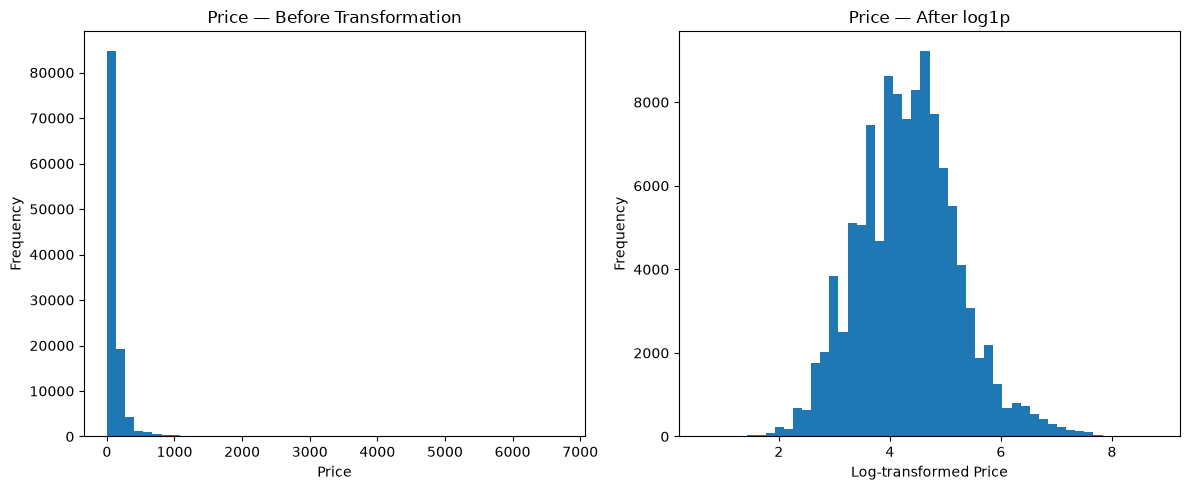

In [28]:
import matplotlib.pyplot as plt

# Price
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(data["price"], bins=50)
plt.title("Price — Before Transformation")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
plt.hist(transformed_data["price_log"], bins=50)
plt.title("Price — After log1p")
plt.xlabel("Log-transformed Price")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

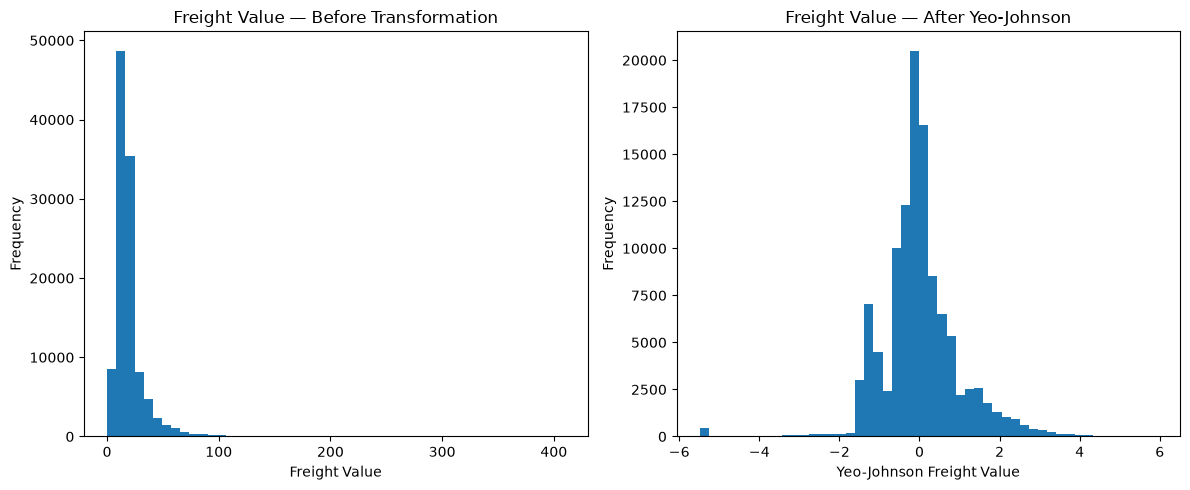

In [29]:
# Freight value
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(data["freight_value"], bins=50)
plt.title("Freight Value — Before Transformation")
plt.xlabel("Freight Value")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
plt.hist(transformed_data["freight_value_yeo"], bins=50)
plt.title("Freight Value — After Yeo-Johnson")
plt.xlabel("Yeo-Johnson Freight Value")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [24]:
import sys
!{sys.executable} -m pip install scikit-learn

  Using cached scikit_learn-1.9.1-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (9.3 kB)
  Using cached scipy-1.18.1-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
  Using cached joblib-1.6.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached narwhals-2.26.0-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.7.0-py3-none-any.whl.metadata (24 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
Using cached scikit_learn-1.9.1-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (9.2 MB)
Using cached joblib-1.6.0-py3-none-any.whl (306 kB)
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
Using cached narwhals-2.26.0-py3-none-any.whl (474 kB)
Using cached scipy-1.18.1-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (35.3 MB)
Using cached threadpoolctl-3.7.0-py3-none-any.whl (26 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [scikit-learn] [scikit-learn]
